# Exploratory Data Analysis (EDA)
## Global Power Plant Database

Download the dataset and have general look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

dPower = pd.read_csv("/content/sample_data/global_power_plant_database.csv")
dPower.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,url,geolocation_source,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,http://globalenergyobservatory.org,GEODB,1009793,2017.0,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,http://globalenergyobservatory.org,GEODB,1009795,2017.0,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,http://globalenergyobservatory.org,GEODB,1009797,2017.0,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,http://globalenergyobservatory.org,GEODB,1009787,2017.0,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,http://globalenergyobservatory.org,GEODB,NaN,2017.0,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
dPower.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29910 entries, 0 to 29909
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   29910 non-null  object 
 1   country_long              29910 non-null  object 
 2   name                      29910 non-null  object 
 3   gppd_idnr                 29910 non-null  object 
 4   capacity_mw               29910 non-null  float64
 5   latitude                  29910 non-null  float64
 6   longitude                 29910 non-null  float64
 7   primary_fuel              29910 non-null  object 
 8   other_fuel1               1963 non-null   object 
 9   other_fuel2               303 non-null    object 
 10  other_fuel3               104 non-null    object 
 11  commissioning_year        16303 non-null  float64
 12  owner                     19531 non-null  object 
 13  source                    29895 non-null  object 
 14  url   

In [3]:
dPower.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,estimated_generation_gwh
count,29910.000000,29910.000000,29910.000000,16303.000000,13743.000000,6996.000000,7440.000000,8144.000000,8971.000000,9213.000000,21791.000000
mean,186.294810,32.497558,-12.458680,1995.486227,2016.860001,689.625437,664.840134,664.270784,583.622877,579.524723,847.036474
std,525.703572,23.654472,76.978265,23.525537,1.195205,2330.869715,2258.351290,2304.225386,2097.603620,2063.070235,4067.434967
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,0.000000
25%,4.774430,28.863475,-79.211275,1986.000000,2017.000000,2.167000,2.157000,2.350250,2.380500,3.202000,10.082961
50%,18.900000,40.071250,-3.746700,2005.000000,2017.000000,27.033000,23.005000,22.094000,17.862000,20.462000,53.417041
75%,100.000000,47.134575,24.931050,2012.063866,2017.000000,250.600500,224.955250,238.437917,187.084835,192.567000,339.874490
max,22500.000000,71.292000,179.388700,2018.000000,2018.000000,50834.000000,32320.917000,59546.865000,32377.477000,35116.000000,450562.692350


#Data Cleaning

##Check for missing values
**Missing Values:**  
Missing values were checked in the dataset. Columns with many missing values were removed, and the remaining missing values were filled with `"Unknown"`.




In [4]:
NSum=dPower.isnull().sum()
print(NSum)

country                         0
country_long                    0
name                            0
gppd_idnr                       0
capacity_mw                     0
latitude                        0
longitude                       0
primary_fuel                    0
other_fuel1                 27947
other_fuel2                 29607
other_fuel3                 29806
commissioning_year          13607
owner                       10379
source                         15
url                            18
geolocation_source            419
wepp_id                     13529
year_of_capacity_data       16167
generation_gwh_2013         22914
generation_gwh_2014         22470
generation_gwh_2015         21766
generation_gwh_2016         20939
generation_gwh_2017         20697
estimated_generation_gwh     8119
dtype: int64


In [5]:
dColumns = NSum[NSum > 500].index

print("\nColumns to DROP:")
print(dColumns)

dPower = dPower.drop(columns=dColumns)


Columns to DROP:
Index(['other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year',
       'owner', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013',
       'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016',
       'generation_gwh_2017', 'estimated_generation_gwh'],
      dtype='object')


In [6]:
dPower.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,source,url,geolocation_source
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,GEODB,http://globalenergyobservatory.org,GEODB
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,GEODB,http://globalenergyobservatory.org,GEODB
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,GEODB,http://globalenergyobservatory.org,GEODB
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,GEODB,http://globalenergyobservatory.org,GEODB
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,GEODB,http://globalenergyobservatory.org,GEODB


In [7]:
dPower.isnull().sum()

,0
country,0
country_long,0
name,0
gppd_idnr,0
capacity_mw,0
latitude,0
longitude,0
primary_fuel,0
source,15
url,18


In [8]:
IColumns = NSum[NSum <500].index
dPower = dPower.fillna("Unknown")

In [9]:
dPower.isnull().sum()

,0
country,0
country_long,0
name,0
gppd_idnr,0
capacity_mw,0
latitude,0
longitude,0
primary_fuel,0
source,0
url,0


##Check for duplicate values
**Duplicates:**  
The dataset was checked for duplicate rows, and no duplicates were found.



In [10]:
print(dPower.duplicated().sum())

0


**Why cleaning was needed:**

The dataset contained missing values, inconsistent formats, and potential duplicate records that could affect analysis accuracy.

**Before and after:**

Before cleaning, multiple columns had a large number of missing values.
After cleaning, irrelevant columns were removed and missing values were handled, resulting in a cleaner and more consistent dataset.

**Changes made:**

Columns with more than 500 missing values were dropped.
Remaining missing values were filled with "Unknown".
The dataset was checked for duplicates, and none were found.



##**visualization**


##Distribution of Power Plants by Primary Fuel
**Why:**

Used to compare the number of plants by fuel type.

**Insights:**

Hydro, solar, and wind are the most common.

**Patterns:**

Renewables appear more frequent than some fossil fuels.

**What we learn:**

Renewable energy sources are widely used globally.

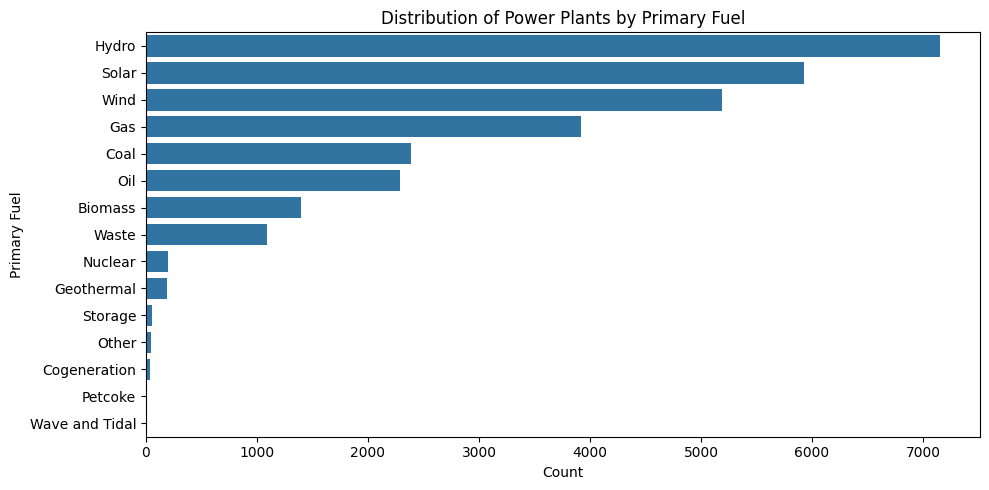

In [11]:
plt.figure(figsize=(10, 5))
fuel_order = dPower["primary_fuel"].value_counts().index
sns.countplot(data=dPower, y="primary_fuel", order=fuel_order)
plt.title("Distribution of Power Plants by Primary Fuel")
plt.xlabel("Count")
plt.ylabel("Primary Fuel")
plt.tight_layout()
plt.show()

##Renewable vs Non-Renewable Power Plants
**Why:**

Used to compare renewable and non-renewable energy sources.

**Insights:**

Renewable sources are slightly more common.

**Patterns:**

Both energy types are still widely used.

**What we learn:**

There is a shift toward renewable energy.

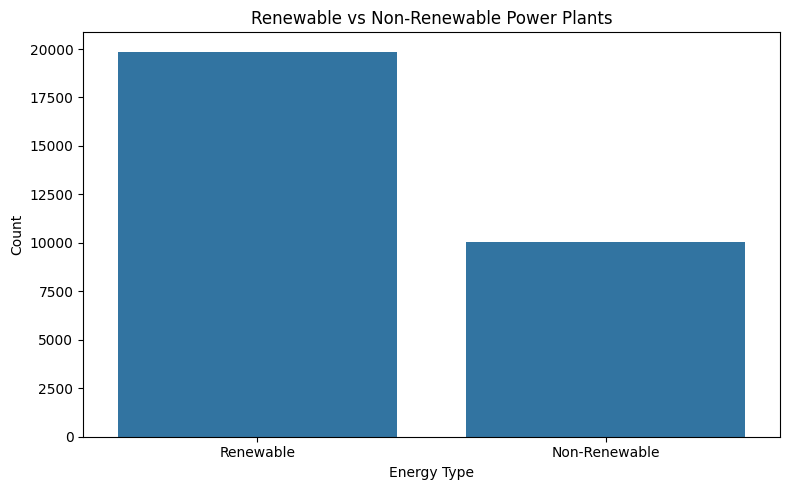

In [12]:
renewable_sources = ["Solar", "Wind", "Hydro", "Geothermal", "Biomass", "Wave and Tidal"]

dPower["energy_type"] = dPower["primary_fuel"].apply(lambda x: "Renewable" if x in renewable_sources else "Non-Renewable")

plt.figure(figsize=(8, 5))
sns.countplot(data=dPower, x="energy_type")
plt.title("Renewable vs Non-Renewable Power Plants")
plt.xlabel("Energy Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Distribution of Power Plant Capacity
**Why:**

Used to understand how capacity values are distributed.

**Insights:**

Most power plants have low capacity.

**Patterns:**

The distribution is highly skewed with a few large outliers.

**What we learn:**

A small number of plants produce very high capacity.r

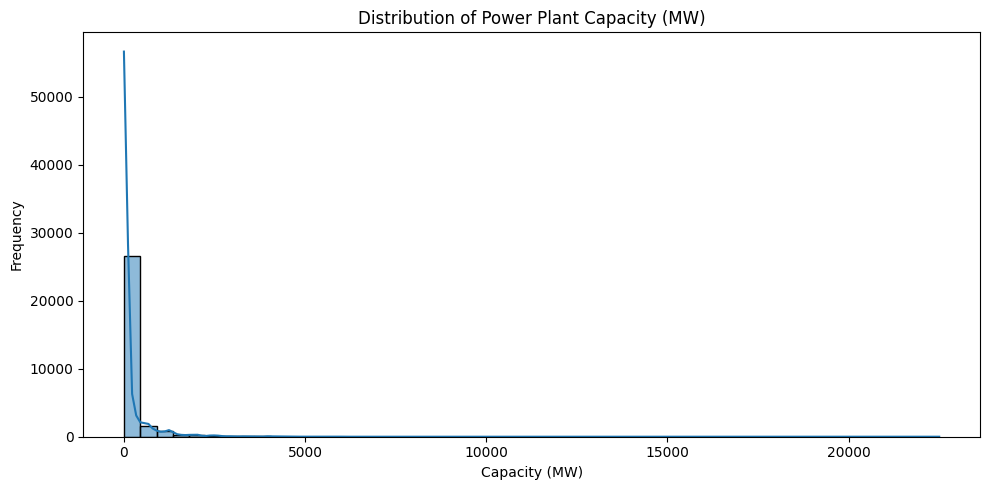

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(dPower["capacity_mw"], bins=50, kde=True)
plt.title("Distribution of Power Plant Capacity (MW)")
plt.xlabel("Capacity (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##Top 10 Countries by Number of Power Plants

**Why:**

Used to compare the number of power plants across countries.

**Insights:**

The United States has the highest number of power plants.

**Patterns:**

A few countries dominate in the number of plants.

**What we learn:**

Energy infrastructure is concentrated in major countries.

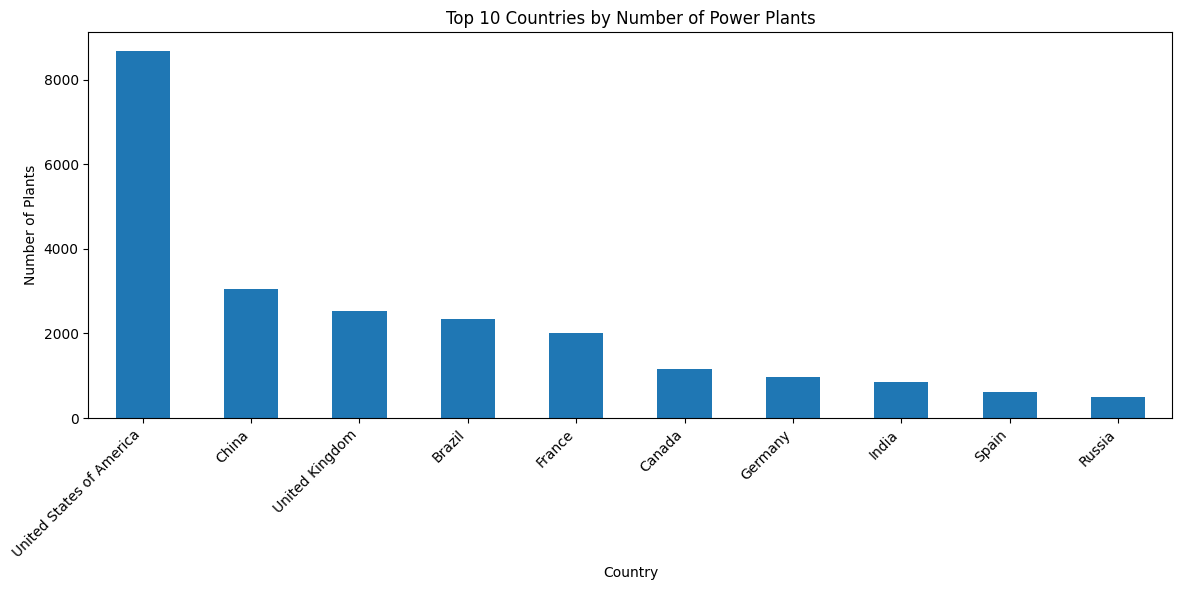

In [14]:
top_countries_count = dPower["country_long"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_countries_count.plot(kind="bar")
plt.title("Top 10 Countries by Number of Power Plants")
plt.xlabel("Country")
plt.ylabel("Number of Plants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##Top 10 Countries by Total

**Why:**

Used to compare total energy capacity across countries.

**Insights:**

China and the United States have the highest total capacity.

**Patterns:**

Some countries have high capacity despite fewer plants.

**What we learn:**

Energy production depends on both number and size of plants.

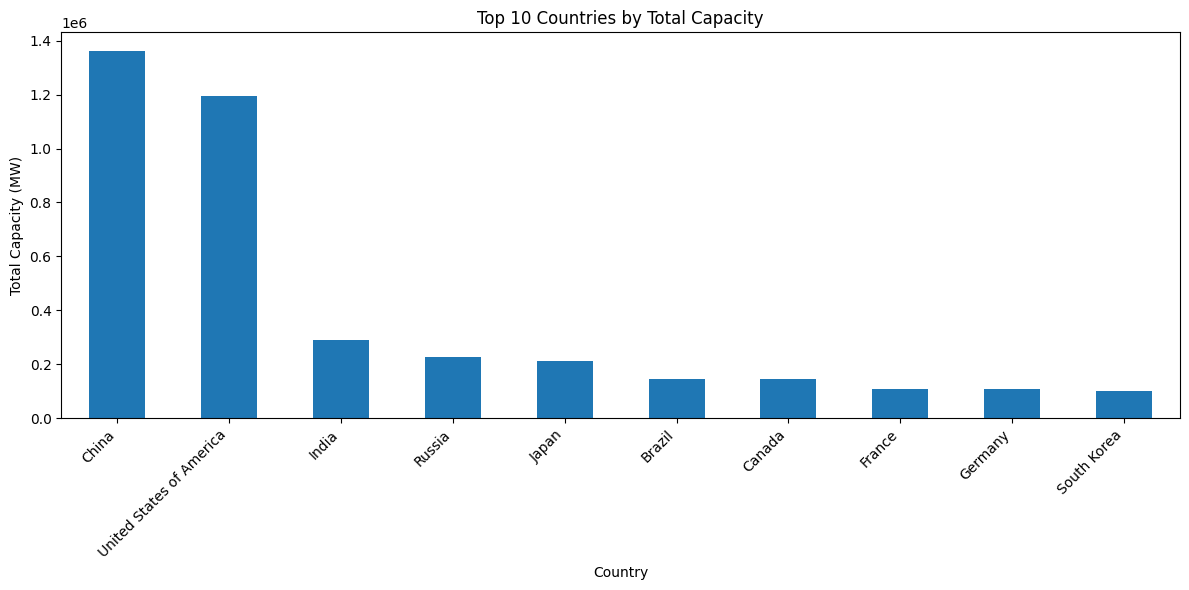

In [15]:
top_countries_capacity = (
    dPower.groupby("country_long")["capacity_mw"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_countries_capacity.plot(kind="bar")
plt.title("Top 10 Countries by Total Capacity")
plt.xlabel("Country")
plt.ylabel("Total Capacity (MW)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##Capacity Distribution by Primary Fuel

**Why:**

Used to compare capacity across fuel types.

**Insights:**

Hydro and nuclear have higher capacity ranges.

**Patterns:**

Many outliers indicate very large power plants.

**What we learn:**

Capacity varies significantly by fuel type.

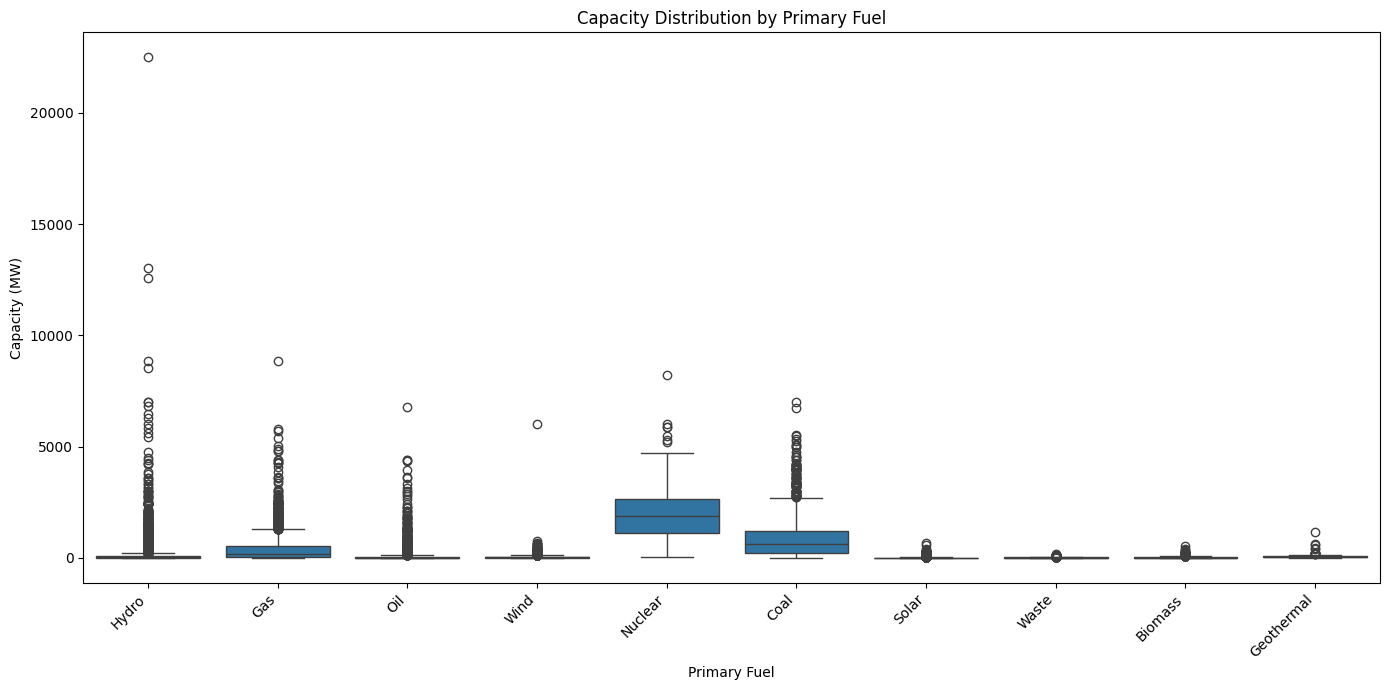

In [16]:
top_fuels = dPower["primary_fuel"].value_counts().head(10).index
dPower_top_fuels = dPower[dPower["primary_fuel"].isin(top_fuels)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=dPower_top_fuels, x="primary_fuel", y="capacity_mw")
plt.title("Capacity Distribution by Primary Fuel")
plt.xlabel("Primary Fuel")
plt.ylabel("Capacity (MW)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##Heatmap (Country vs Fuel)

**Why:**

Used to compare fuel types across countries.

**Insights:**

Some countries depend on specific fuel types.

**Patterns:**

Energy usage differs clearly between countries.

**What we learn:**

Each country has a different energy strategy.



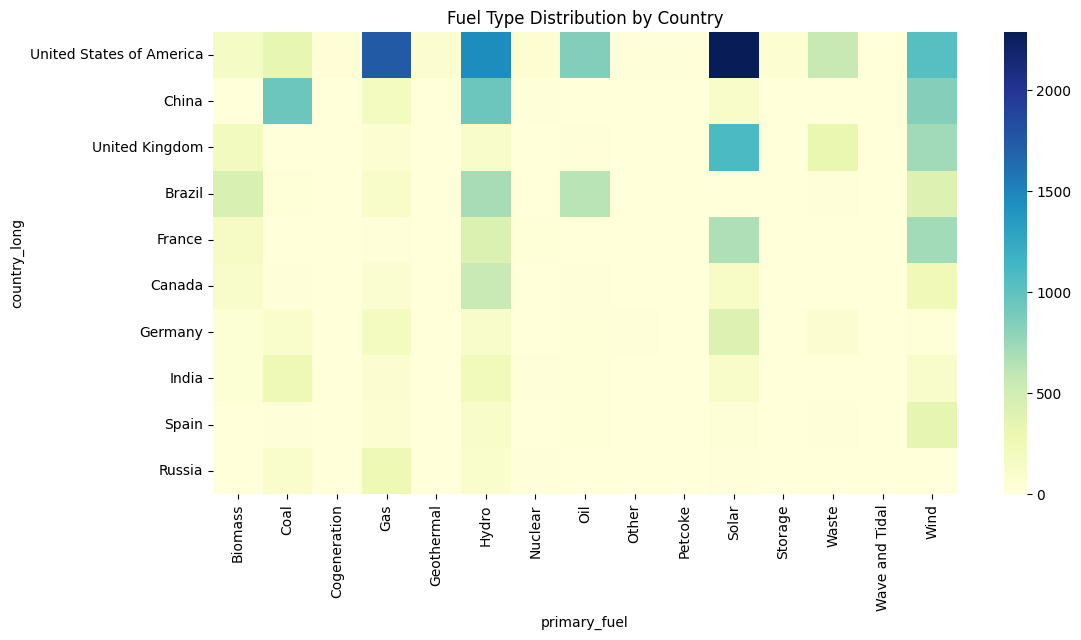

In [17]:
pivot_table = pd.crosstab(dPower["country_long"], dPower["primary_fuel"])

top_countries = dPower["country_long"].value_counts().head(10).index
pivot_table = pivot_table.loc[top_countries]

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap="YlGnBu")
plt.title("Fuel Type Distribution by Country")
plt.show()

In [18]:
dPower.to_excel("cleaned_power_data.xlsx", index=False)